# Librairies à utiliser

In [1]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(GGally)
library(dplyr)



── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout


corrplot 0.95 loaded


Attachement du package : 'reshape2'


L'objet suiv

# 1. Récupération du jeu de données

In [19]:
data<-read.csv("healthcare_synthetic_data.csv")
summary(data)
head(data)

  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Nous avons décidé de supprimer la variable Patient_ID car étant unique pour chaque patient, elle ne donne pas d'information exploitable.

Nous convertissons les variables qualitatives en "facteurs" ('Gender','Smoking_Status', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity_Level','Heart_Disease_Risk').

Nous choisissons aussi de traiter 'Stress_Level' et 'Sleep_Hours' comme des variables qualitatives au vu de leur petit nombre de valeurs distinctes.

In [20]:
paste("Le nombre de valeurs distinctes que prend la variable Stress_Level est :",n_distinct(data[,"Stress_Level"]))
paste("Le nombre de valeurs distinctes que prend la variable Sleep_Hours est :",n_distinct(data[,"Sleep_Hours"]))

[1] "Le nombre de valeurs distinctes que prend la variable Stress_Level est : 10"

[1] "Le nombre de valeurs distinctes que prend la variable Sleep_Hours est : 7"

In [21]:
# Suppression de la variable Patient_ID
data=data %>% select(-Patient_ID)

data[, "Gender"] <- as.factor(data[, "Gender"])
data$Gender <- factor(data$Gender, 
                      levels = c(0, 1), 
                      labels = c("Female", "Male"))
data[,"Smoking_Status"]= as.factor(data[,"Smoking_Status"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[,"Stress_Level"]= as.factor(data[,"Stress_Level"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[,"Sleep_Hours"]= as.factor(data[,"Sleep_Hours"])
summary(data)

      Age           Gender       Height_cm       Weight_kg           BMI       
 Min.   :25.00   Female:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   Male  :7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00                 Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54                 Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00                 3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00                 Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                               
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd

Au final :

Les variables **quantitatives** sont : Age, Height_cm, Weight_kg, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_LDL, Cholesterol_HDL, Fasting_Blood_Sugar.


Les variables **qualitatives** sont : Gender, Smoking_Status, Alcohol_Consumption, Physical_Activity_Level, Heart_Disease_Risk, Family_History, Stress_Level, Sleep_Hours.

# 2. Analyse exploratoire des données

## 2.1 Analyse unidimentionnelle

### Variables quantitatives

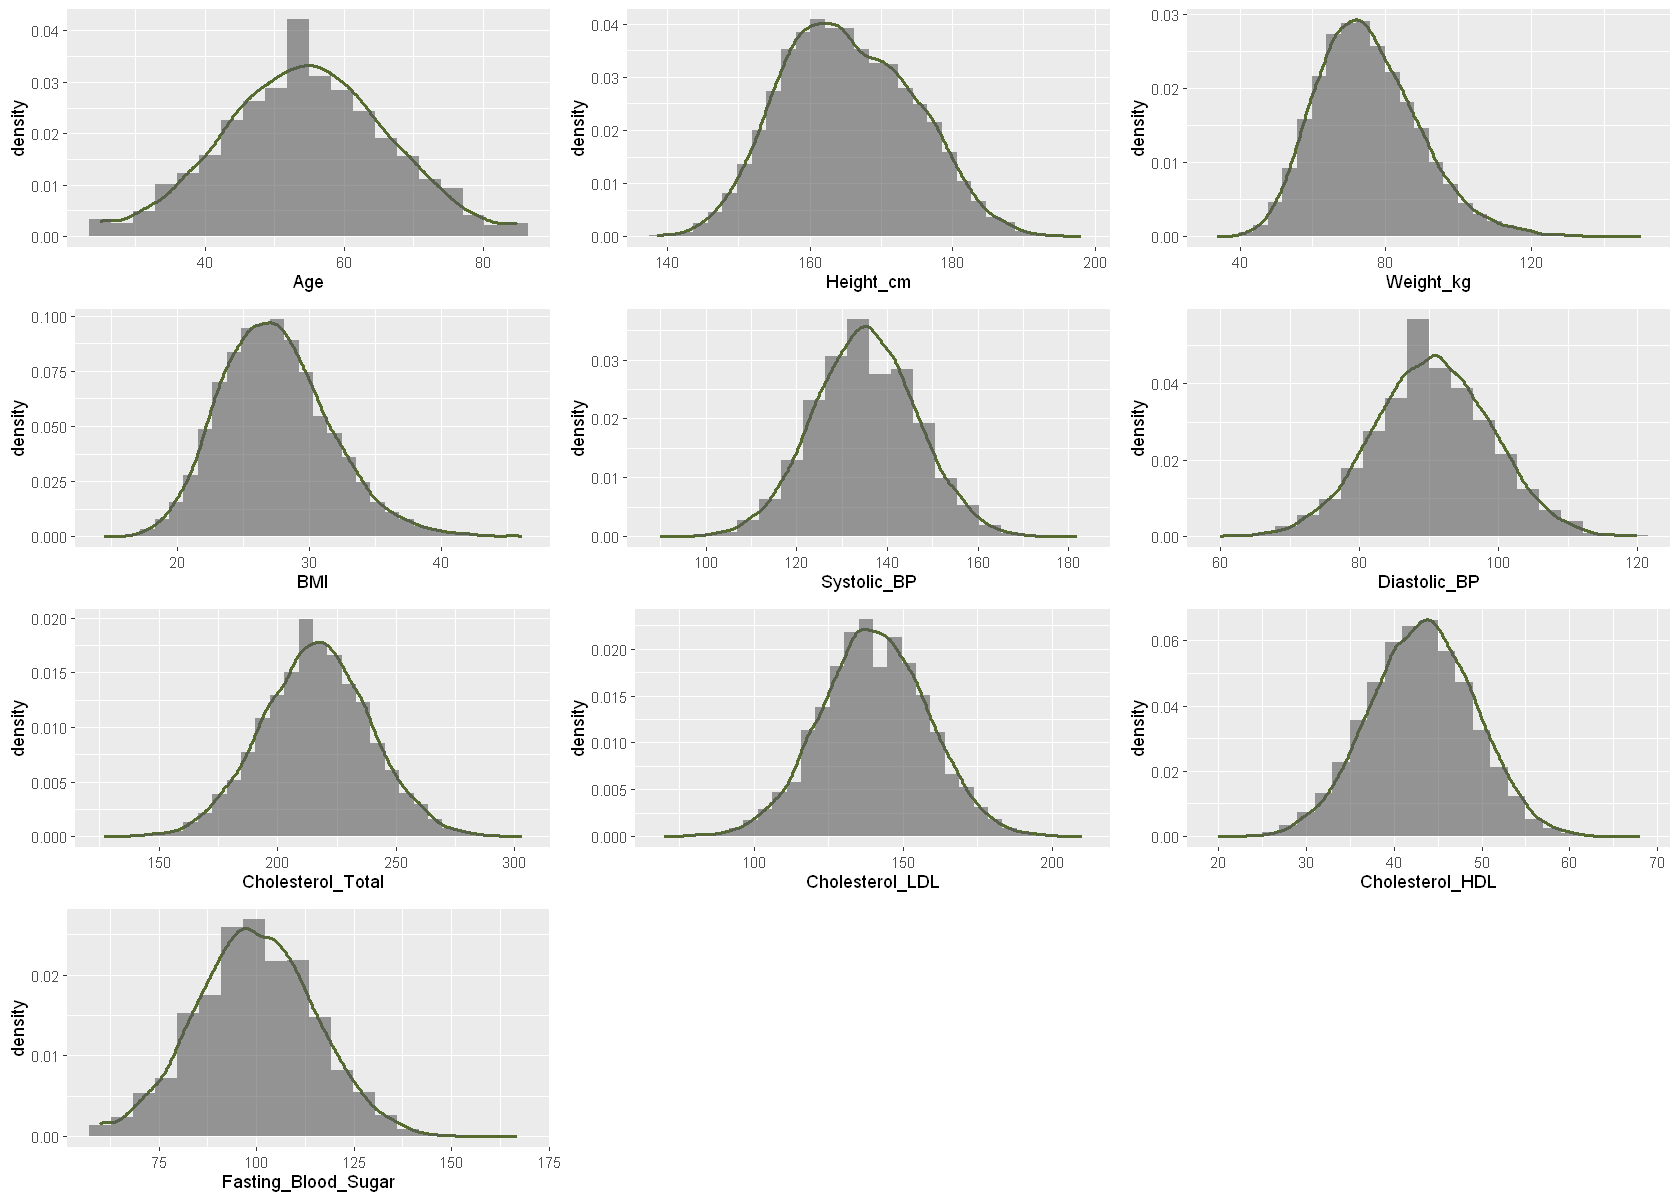

In [22]:
# Etude densité des variables quantitatives
g1=ggplot(data,aes(x=Age)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g2=ggplot(data,aes(x=Height_cm)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g3=ggplot(data,aes(x=Weight_kg)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g4=ggplot(data,aes(x=BMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g5=ggplot(data,aes(x=Systolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g6=ggplot(data,aes(x=Diastolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
g7=ggplot(data,aes(x=Cholesterol_Total)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g8=ggplot(data,aes(x=Cholesterol_LDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
g9=ggplot(data,aes(x=Cholesterol_HDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=25)
g10=ggplot(data,aes(x=Fasting_Blood_Sugar)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)

options(repr.plot.width = 14, repr.plot.height = 10)
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,ncol=3)

Fasting_Blood_Sugar, Height_cm et BMI semblent légèrement asymétriques à droite, on leur a donc appliquer une racine carré pour les rendre plus symétriques. On a aussi choisi de modifier Height_cm en lui appliquant un logarithme.

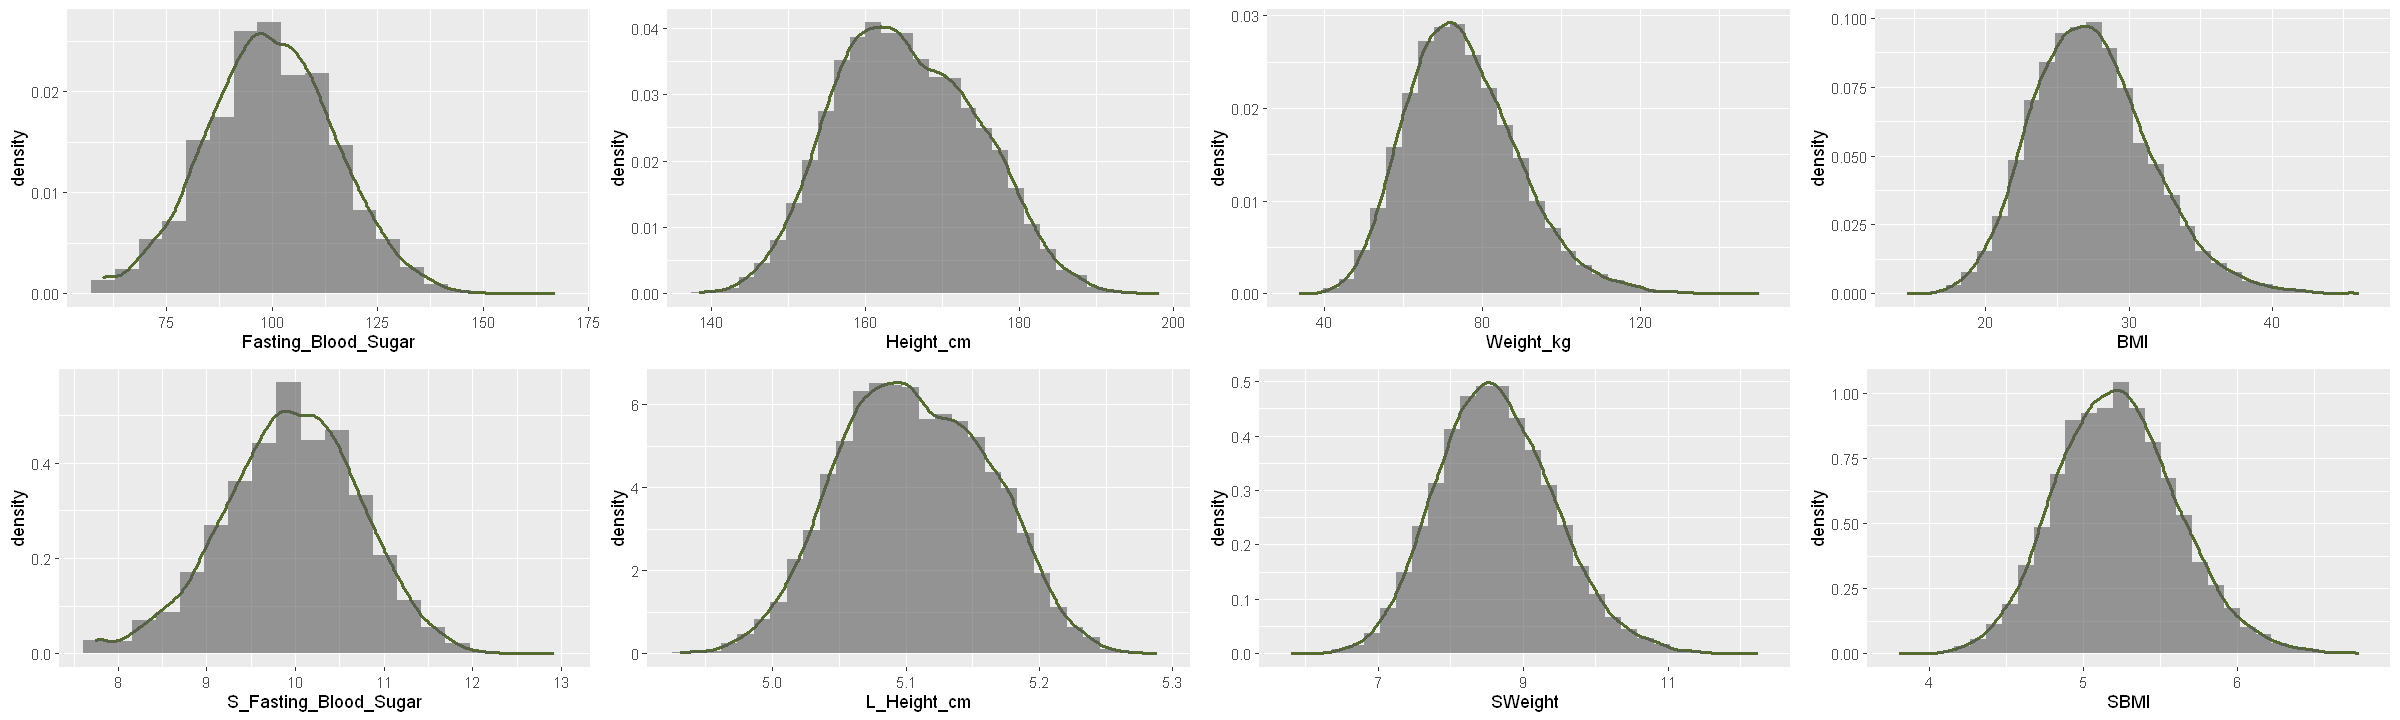

In [23]:
options(repr.plot.width = 20, repr.plot.height = 6)
data[,"SBMI"] = sqrt(data[,"BMI"])
data[,"SWeight"] = sqrt(data[,"Weight_kg"])
data[, "S_Fasting_Blood_Sugar"] = sqrt(data[, "Fasting_Blood_Sugar"])
data[, "L_Height_cm"] = log(data[, "Height_cm"])

sg1=ggplot(data,aes(x=S_Fasting_Blood_Sugar))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=20)
sg2=ggplot(data,aes(x=L_Height_cm))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
sg4=ggplot(data,aes(x=SBMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
sg3=ggplot(data,aes(x=SWeight)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=30)
grid.arrange(g10,g2,g3,g4,sg1,sg2,sg3,sg4,ncol=4)

In [24]:
#On ne garde que les variables transformées
data=data %>% select(-c(Fasting_Blood_Sugar,Height_cm,Weight_kg,BMI))
summary(data)

      Age           Gender      Systolic_BP     Diastolic_BP   
 Min.   :25.00   Female:7622   Min.   : 90.0   Min.   : 60.00  
 1st Qu.:46.00   Male  :7378   1st Qu.:127.0   1st Qu.: 85.00  
 Median :55.00                 Median :135.0   Median : 91.00  
 Mean   :54.54                 Mean   :135.1   Mean   : 90.54  
 3rd Qu.:63.00                 3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :85.00                 Max.   :182.0   Max.   :120.00  
                                                               
 Cholesterol_Total Cholesterol_LDL Cholesterol_HDL Smoking_Status
 Min.   :127.0     Min.   : 70.0   Min.   :20.00   0:10495       
 1st Qu.:201.0     1st Qu.:128.0   1st Qu.:39.00   1: 4505       
 Median :216.0     Median :140.0   Median :43.00                 
 Mean   :216.2     Mean   :140.4   Mean   :43.31                 
 3rd Qu.:231.0     3rd Qu.:152.0   3rd Qu.:47.00                 
 Max.   :303.0     Max.   :210.0   Max.   :68.00                 
                          

### Variables qualitatives

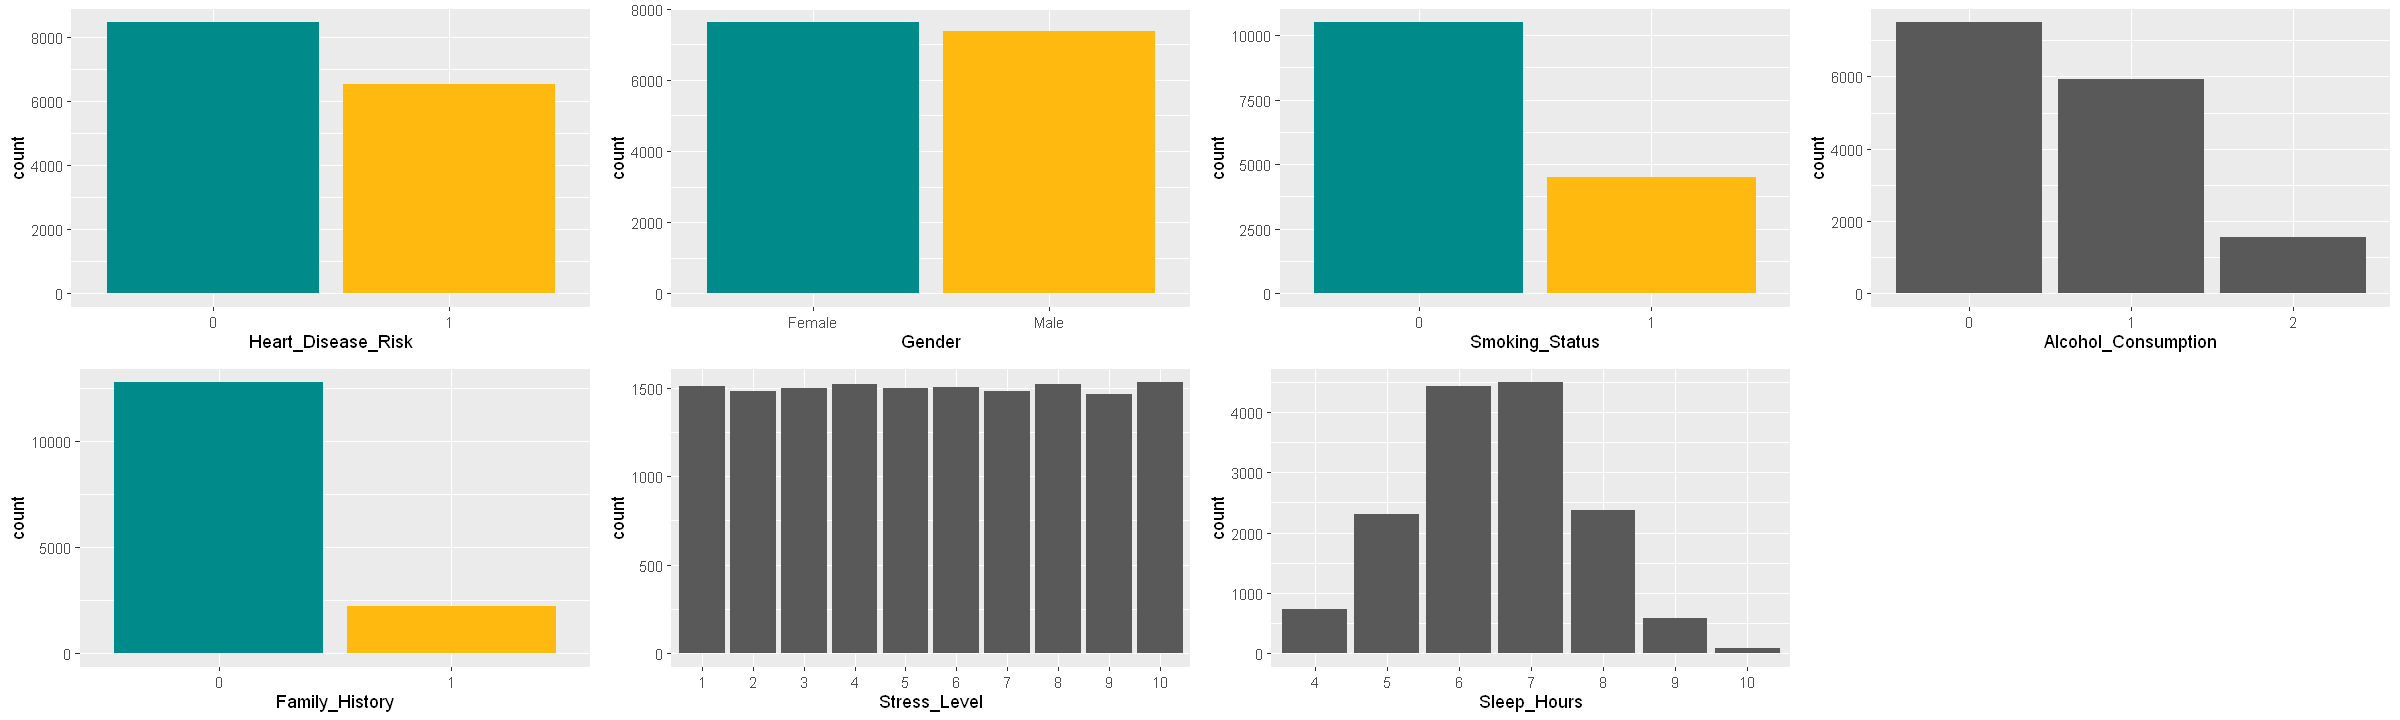

In [44]:
# Affichage des fréquences des modalités
colors=c("darkcyan","darkgoldenrod1")
p1=ggplot(data,aes(x=Heart_Disease_Risk))+geom_bar(fill=colors)
p2=ggplot(data,aes(x=Gender))+geom_bar(fill=colors)
p3=ggplot(data,aes(x=Smoking_Status))+geom_bar(fill=colors)
p4=ggplot(data,aes(x=Alcohol_Consumption))+geom_bar()
p5=ggplot(data,aes(x=Physical_Activity_Level))+geom_bar()
p5=ggplot(data,aes(x=Family_History))+geom_bar(fill=colors)
p6=ggplot(data,aes(x=Stress_Level))+geom_bar()
p7=ggplot(data,aes(x=Sleep_Hours))+geom_bar()
grid.arrange(p1,p2,p3,p4,p5,p6,p7,ncol=4)

Toutes les modalités ont l'air d'être bien représentées et l'échantillon intérrogé semple représentatif de la population; 

## 2.2 Analyse bidimensionnelle

### Corrélation entre variables quantitatives

In [47]:
options(repr.plot.width = 14, repr.plot.height = 7)

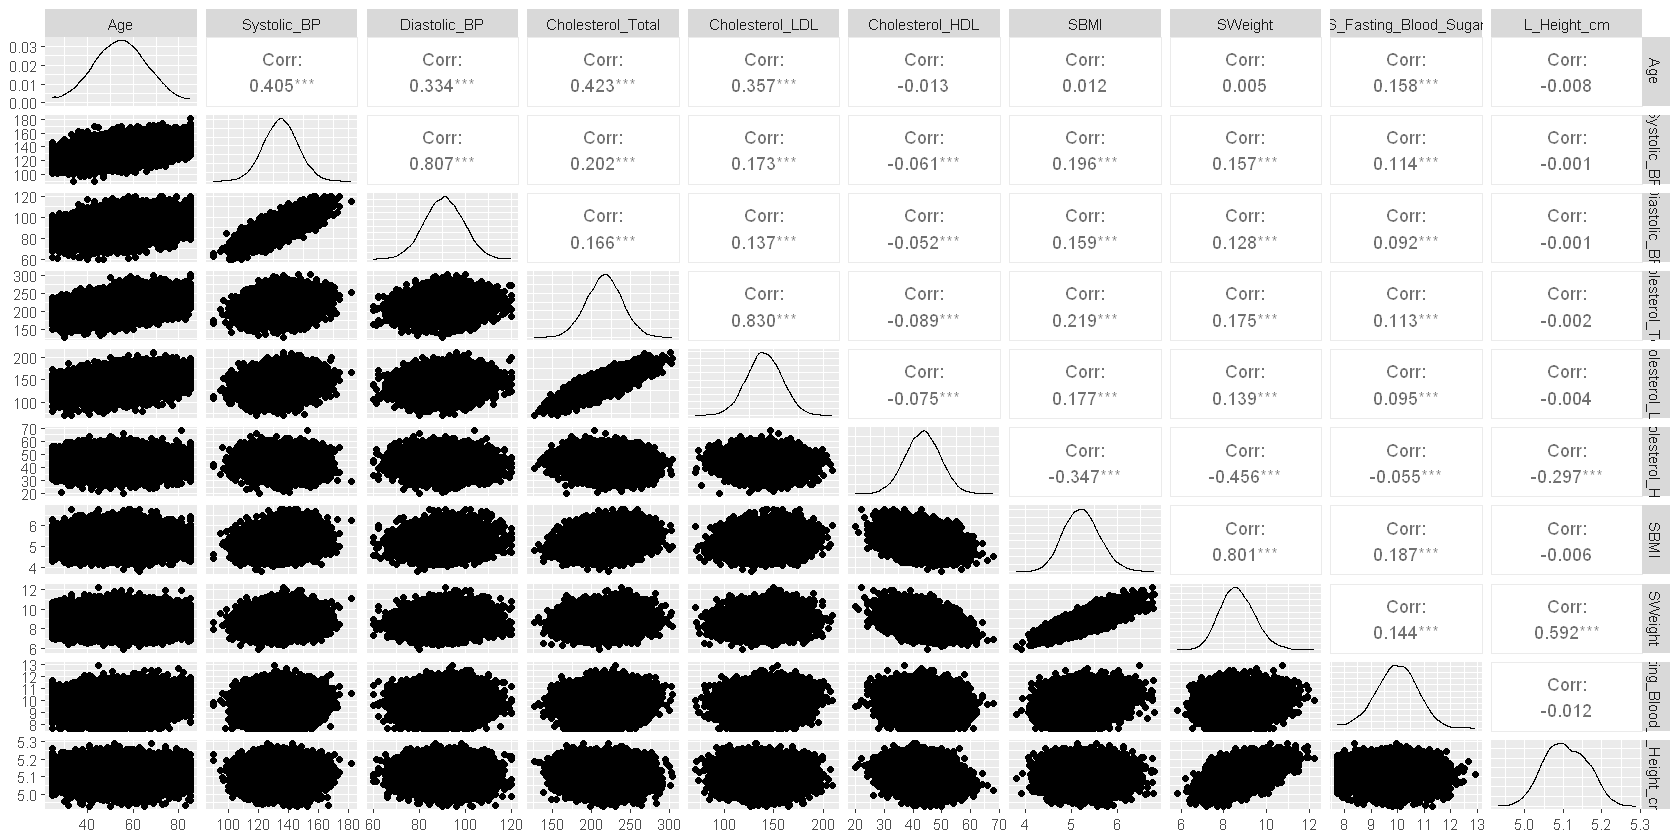

In [48]:
data_quanti = data %>% select(where(is.numeric))
ggpairs(data_quanti)

On remarque 3 paires de variables très corrélées positivement (avec des valeurs de correlation autour de 0.8): le **poids du patient** avec **l'IMC**, la **pression artérielle systolique** (Systotic_BP) avec la **pression artérielle diastolique** (Diastotic_BP) et le taux de **cholesterol total** avec le taux de **cholesterol LDL**. On note aussi que la variable **Height** est corrélé positivement avec **SWeight** (presque 0.6).

Cela semble logique car le calcul de l'IMC dépend du poids, les variables Diastotic_BP et Systotic_BP mesurent toutes les deux la pression artérielle et enfin le cholesterol LDL fait partie du cholesterol total. Cependant on remarque que le taux de cholesterol total soit très corrélé avec le taux de cholesterol LDL ("mauvais") mais pas avec le HDL ("bon") (correlation de 0.830 contre -0.089). Les deux types de cholesterol ne semblent pas non plus corrélées entre eux. On suppose donc que le mauvais cholesterol est présent en majorité dans le taux de chomesterol total.

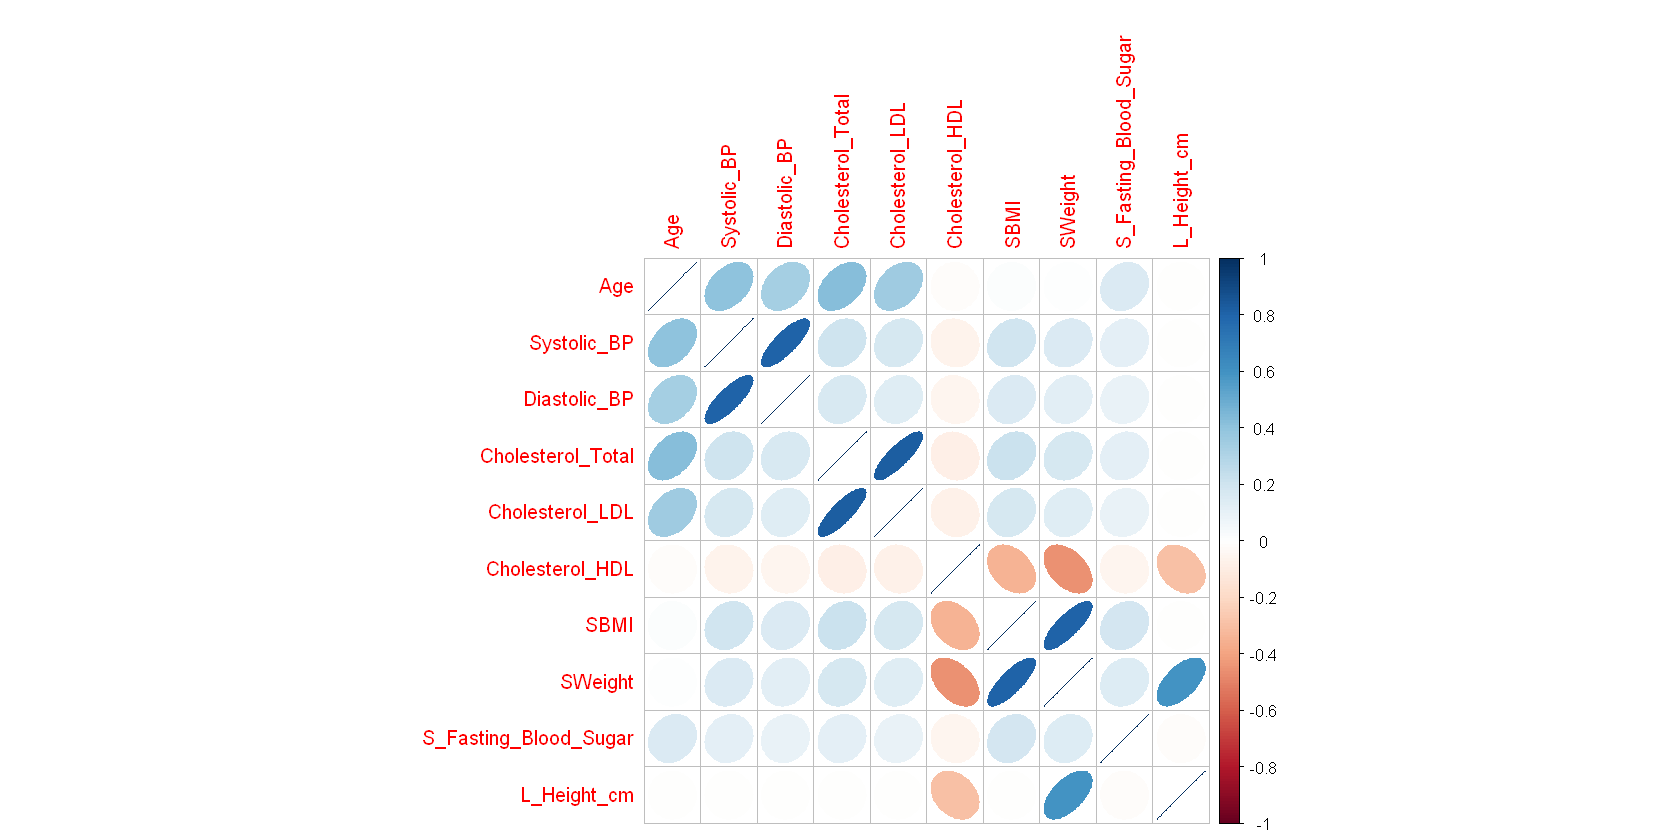

In [49]:
corrplot(cor(data_quanti),method="ellipse")

Cette deuxième représentation des corrélations confirme nos conclusions.

### Corrélations entre variables qualitatives et quantitatives

On s'intéresse dans cette partie aux corrélations entre les differentes variables quantitatives sur la variable Heart_Disease_Risk et l'effet des variables qualitatives sur la variable Cholesterol_LDL car c'est elles que nous allons prédire par la suite.

**Etude de la relation entre les différents taux de cholesterol et le risque cardiaque en fonction du genre**

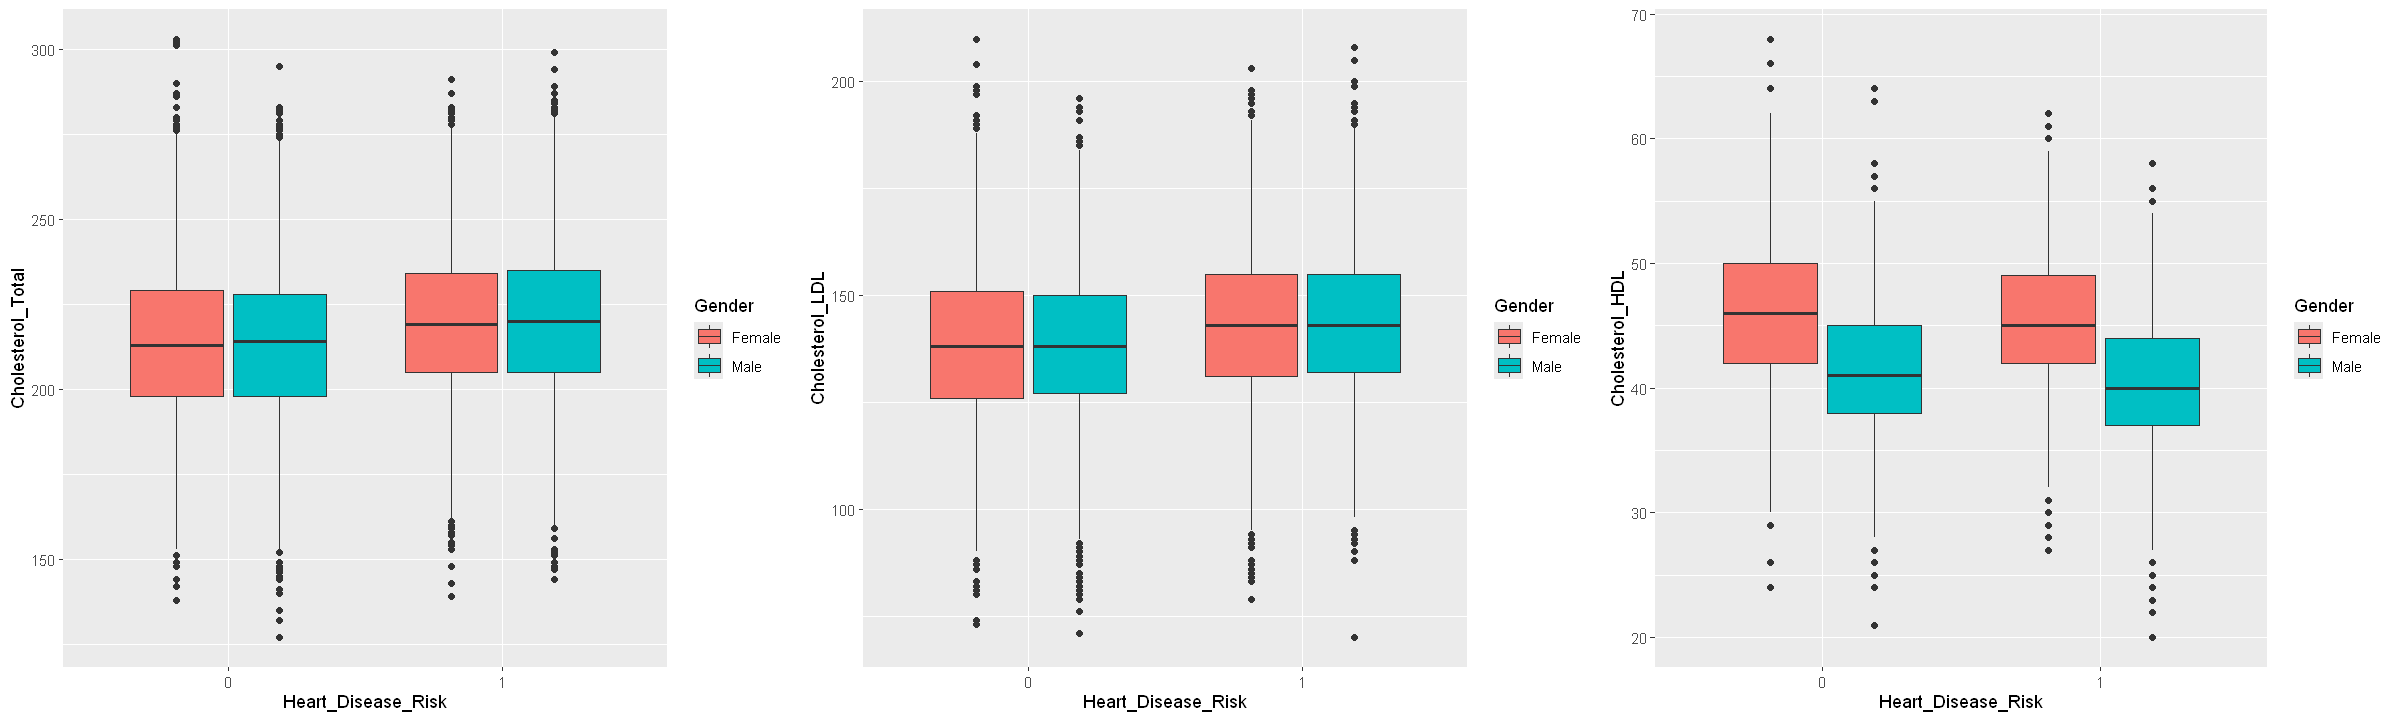

In [61]:
options(repr.plot.width = 20, repr.plot.height = 6)
gg1=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_Total,fill = Gender)) +geom_boxplot()
gg2=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_LDL,fill = Gender)) +geom_boxplot()
gg3=ggplot(data, aes(x = Heart_Disease_Risk, y= Cholesterol_HDL,fill = Gender)) +geom_boxplot()
grid.arrange(gg1,gg2,gg3,ncol=3)

On remarque que le taux de cholesterol total est plus élevé chez les personnes qui ont un risque élevé d'accident cardiaque. Lorsqu'on regarde en détail, le cholesterol LDL est lui aussi en plus grande quantité chez les personne à risque d'accident cardiaque. En revanche, le taux de cholesterol HDL est plus bas chez ces mêmes personnes. A noter aussi, que pour le cholestérol HDL les femmes ont naturellement un taux plus élevé que les hommes.

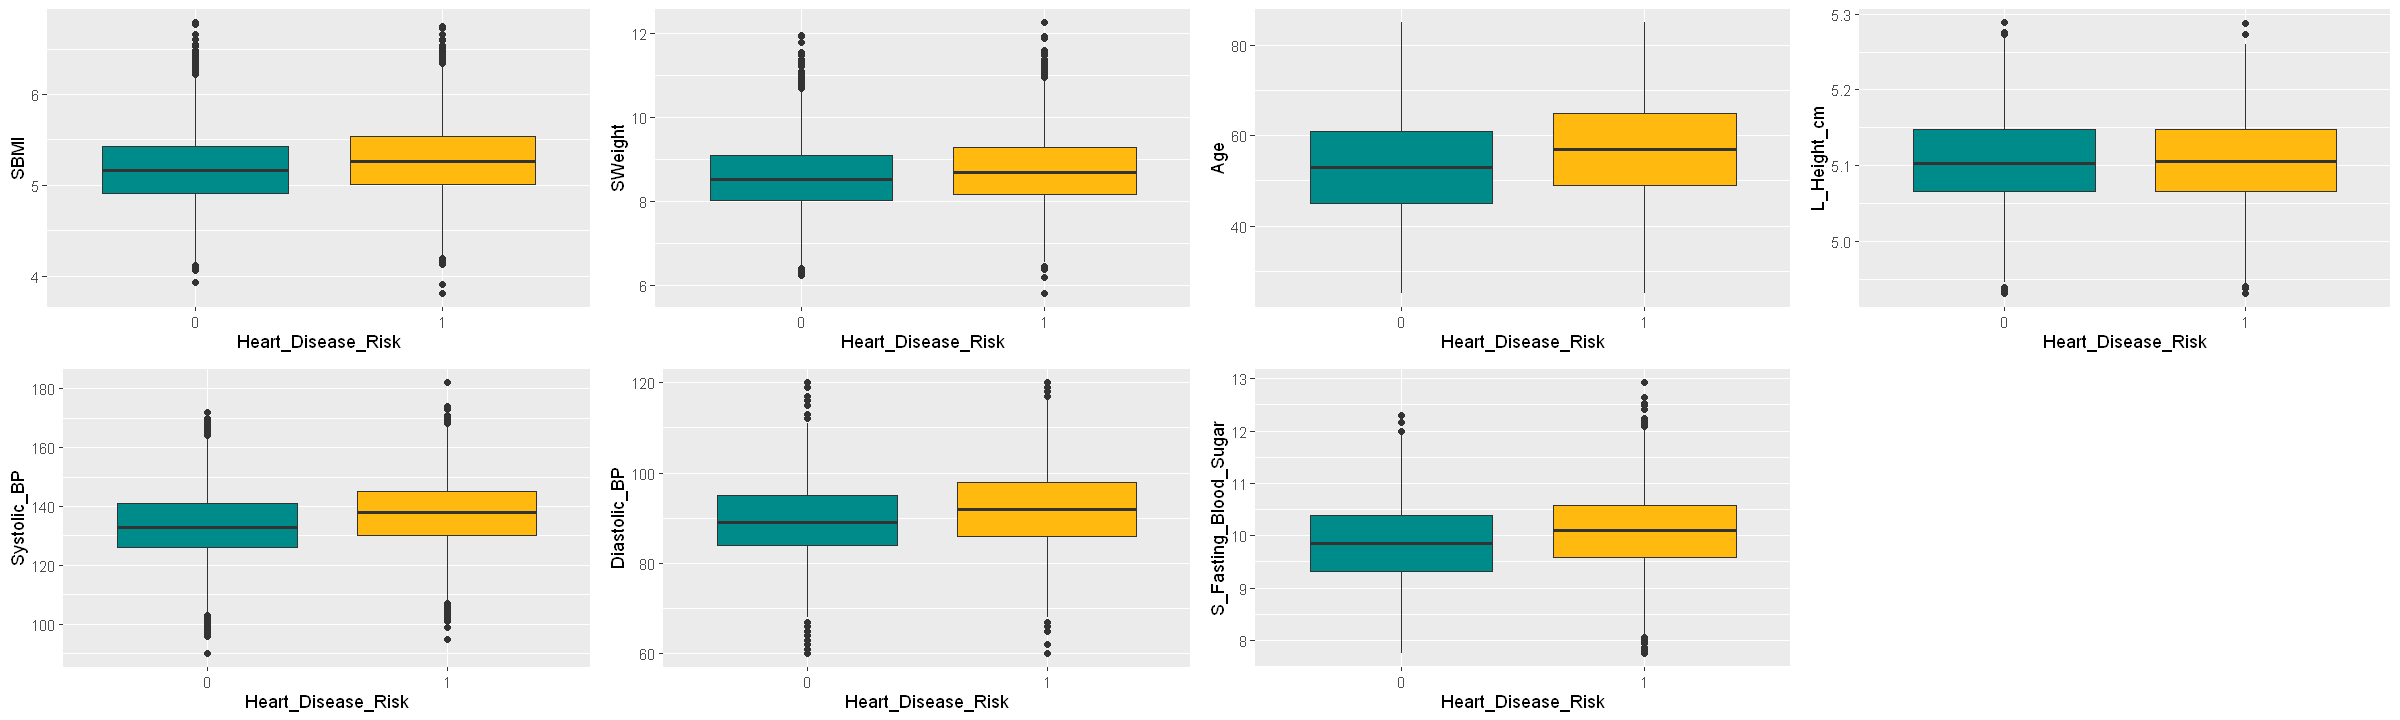

In [65]:
gg4 = ggplot(data,aes(x = Heart_Disease_Risk, y= SBMI)) + geom_boxplot(fill=colors)
gg5 = ggplot(data,aes(x = Heart_Disease_Risk, y=SWeight)) + geom_boxplot(fill=colors)
gg6 = ggplot(data,aes(x = Heart_Disease_Risk, y=Age)) + geom_boxplot(fill=colors)
gg7 = ggplot(data,aes(x = Heart_Disease_Risk, y=L_Height_cm)) + geom_boxplot(fill=colors)
gg8 = ggplot(data,aes(x = Heart_Disease_Risk, y=Systolic_BP)) + geom_boxplot(fill=colors)
gg9 = ggplot(data,aes(x = Heart_Disease_Risk, y=Diastolic_BP)) + geom_boxplot(fill=colors)
gg10 = ggplot(data,aes(x = Heart_Disease_Risk, y=S_Fasting_Blood_Sugar)) + geom_boxplot(fill=colors)
grid.arrange(gg4,gg5,gg6,gg7,gg8,gg9,gg10,ncol=4)

On remarque que les variables liés à la tension artérielle ont une influence sur le risque d'accident vasculaire. De plus, L'IMC, le poids, l'âge et le taux de glycémie à un jeun jouent un rôle dans le risque d'accident cardiaque

### Corrélation qualitatif-qualitatif

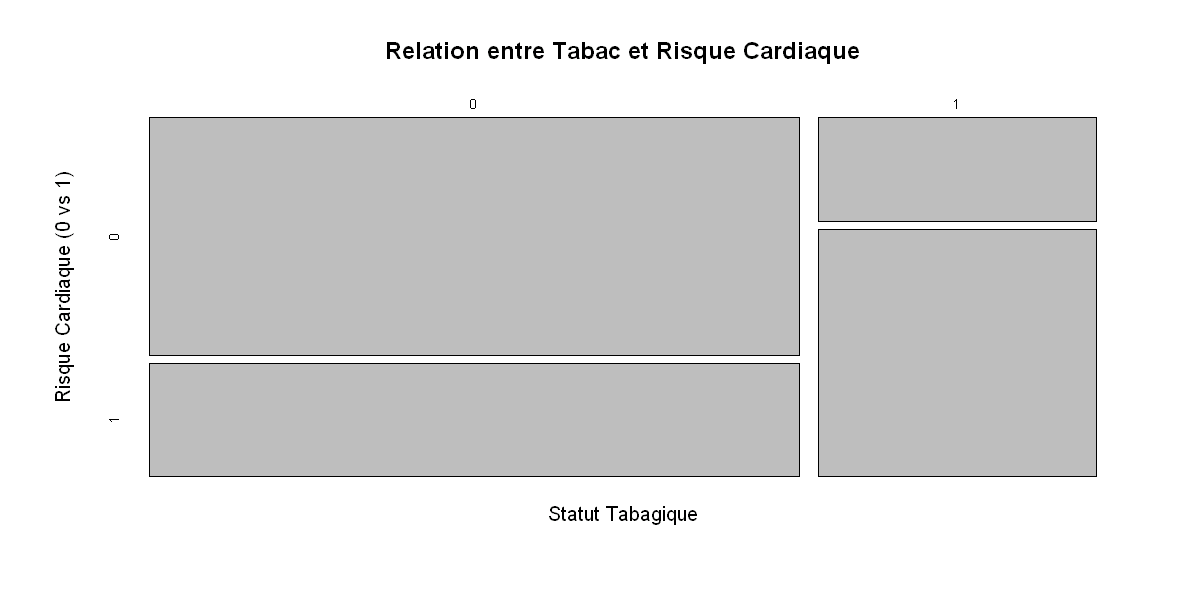

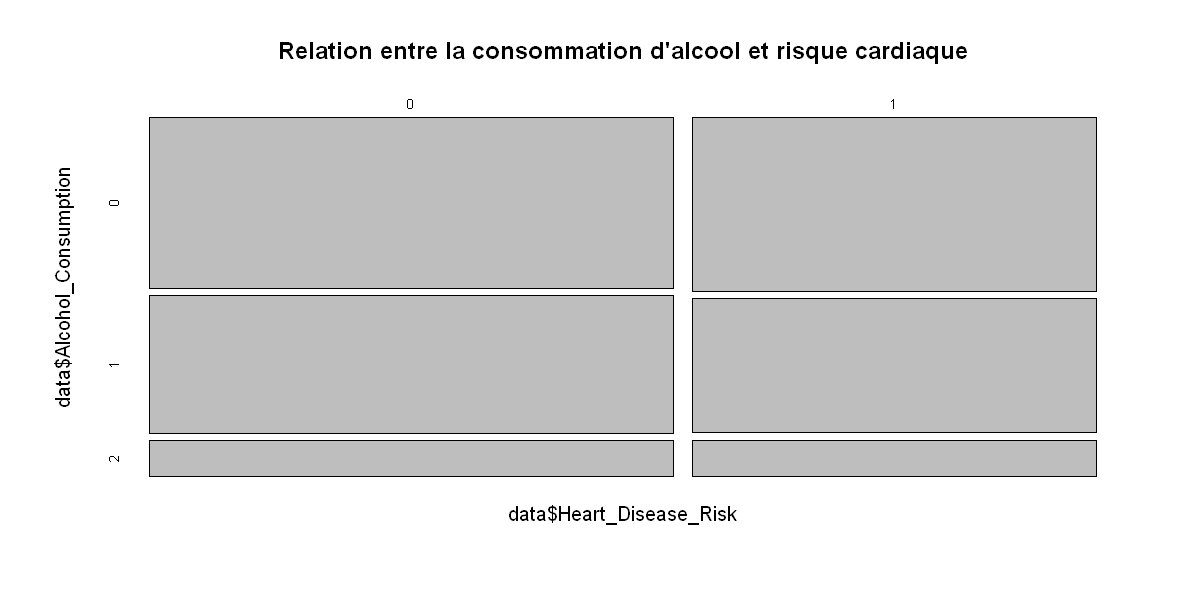

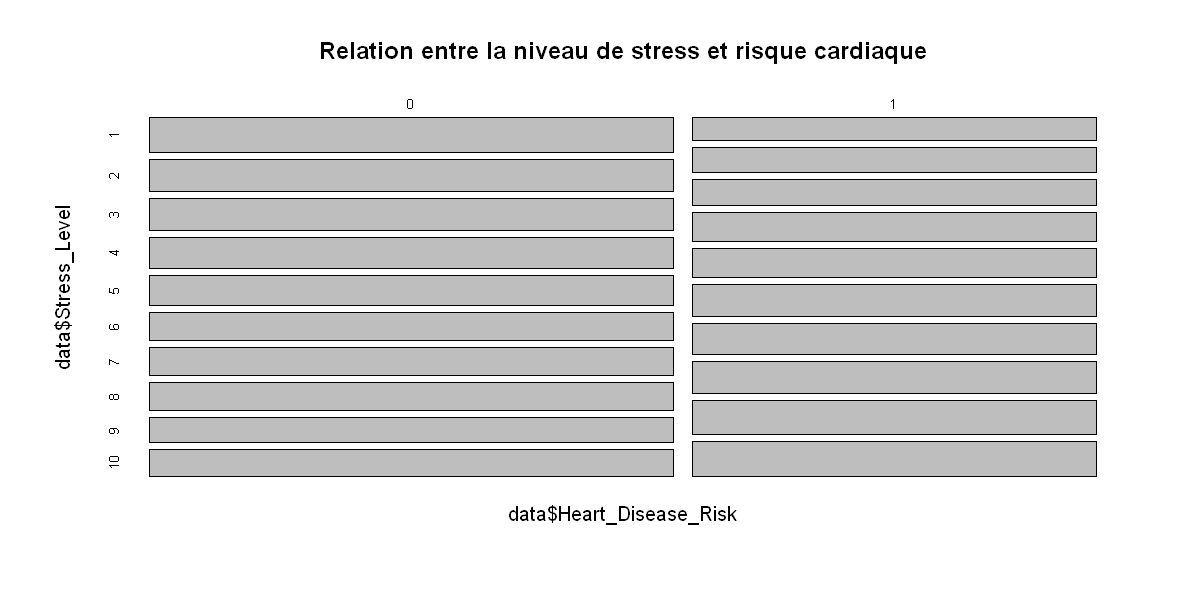

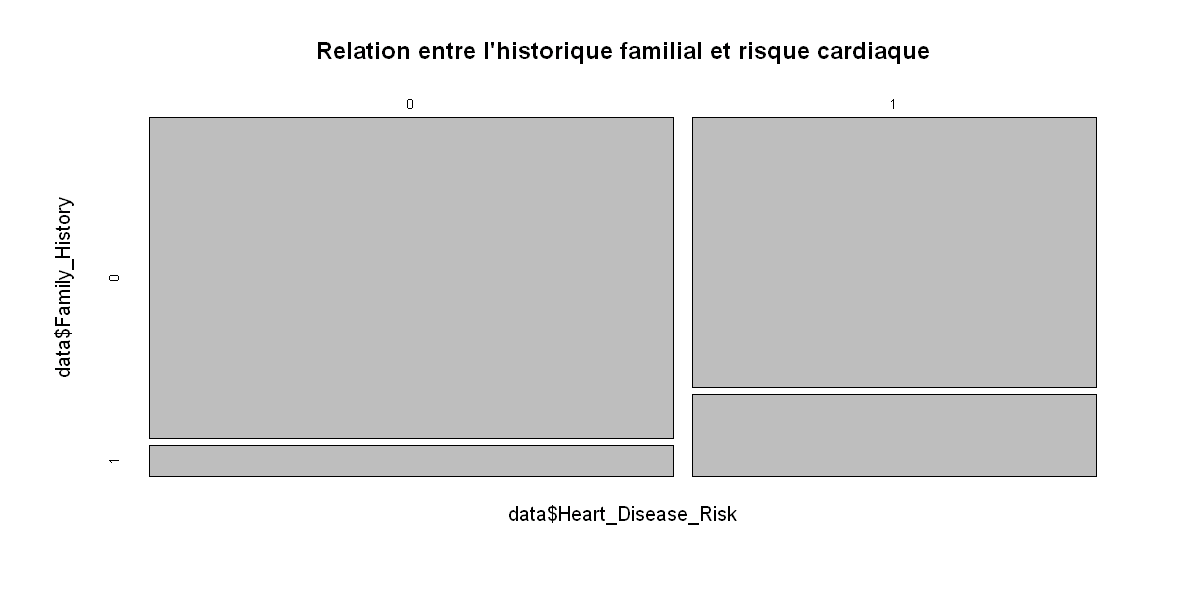

In [12]:
#Rendre jolie les labels ? 
mosaicplot(data$Smoking_Status~data$Heart_Disease_Risk,main = "Relation entre Tabac et Risque Cardiaque",xlab = "Statut Tabagique",ylab = "Risque Cardiaque (0 vs 1)")
mosaicplot(data$Heart_Disease_Risk~ data$Alcohol_Consumption,main="Relation entre la consommation d'alcool et risque cardiaque")
mosaicplot(data$Heart_Disease_Risk~ data$Stress_Level,main="Relation entre la niveau de stress et risque cardiaque")
mosaicplot(data$Heart_Disease_Risk~ data$Family_History,main="Relation entre l'historique familial et risque cardiaque")

# ACP

Puisque nous avons des variables avec des valeurs très différentes, il est nécessaire de centrer et réduire les données(scale.unit=TRUE).

In [13]:
res_pca=PCA(data_quanti, scale.unit = TRUE, graph = TRUE)
res_pca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,2.920380259,29.20380259,29.20380
comp 2,2.037915226,20.37915226,49.58295
comp 3,1.480190242,14.80190242,64.38486
comp 4,1.056831036,10.56831036,74.95317
comp 5,0.907168905,9.07168905,84.02486
comp 6,0.686433196,6.86433196,90.88919
comp 7,0.556520101,5.56520101,96.45439
comp 8,0.188839990,1.88839990,98.34279
comp 9,0.164500697,1.64500697,99.98780
comp 10,0.001220346,0.01220346,100.00000


On va garder les 5 premières composantes principales car à elles, elles expliquent plus de 80% de la variance.

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


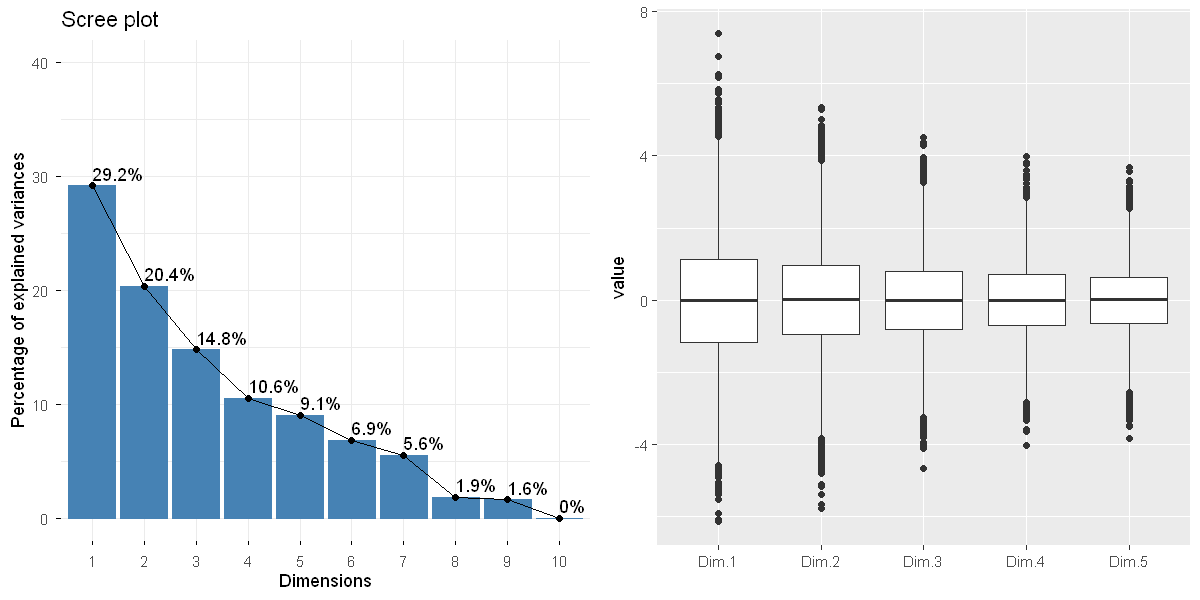

In [14]:
g1<-fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 40))
g2<-ggplot(melt(res_pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

On remarque que les deux premières dimensions portent près de 50% de l'information, on voit que le coude est présent entre la 2ème et 3ème dimension, on va pouvoir se concentrer sur le premier plan factoriel pour la suite des analyses


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


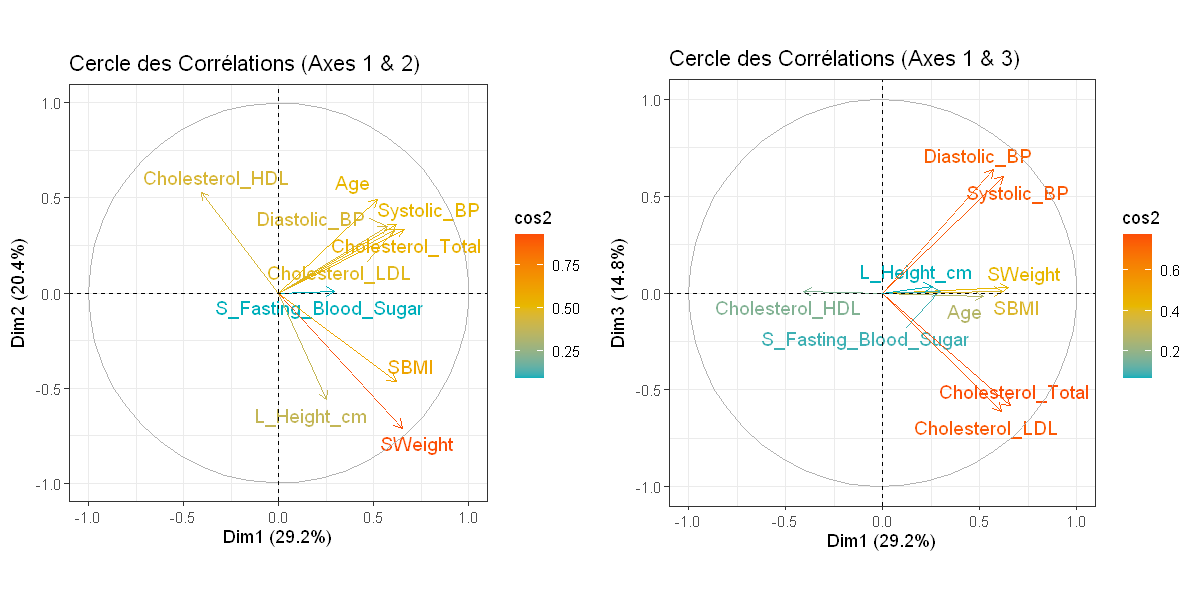

In [15]:

v1 <- fviz_pca_var(res_pca, axes=c(1,2), col.var="cos2",
                   gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
                   repel = TRUE) + 
  labs(title = "Cercle des Corrélations (Axes 1 & 2)") + theme_bw()


v2 <- fviz_pca_var(res_pca, axes=c(1,3), col.var="cos2",
                   gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
                   repel = TRUE) + 
  labs(title = "Cercle des Corrélations (Axes 1 & 3)") + theme_bw()

grid.arrange(v1, v2, ncol=2)

L'examen des deux premiers plans factoriels révèle une organisation du risque autour de trois dimensions indépendantes : le plan 1-2 met en évidence un pôle « morpho-tensionnel » (forte corrélation entre le BMI et les pressions artérielles sur l'axe 1) totalement orthogonal à un pôle « lipidique » (porté par le cholestérol LDL sur l'axe 2). Le plan 1-3 complète cette analyse en faisant émerger des facteurs isolés, comme l'âge et le cholestérol HDL, qui apportent une information complémentaire non captée par la corpulence ou le mauvais cholestérol. Cette structure confirme la nécessité de traiter séparément ces leviers biologiques lors de la modélisation et souligne la redondance critique entre le poids et l'IMC, qu'il faudra arbitrer pour éviter tout biais de multicolinéarité.

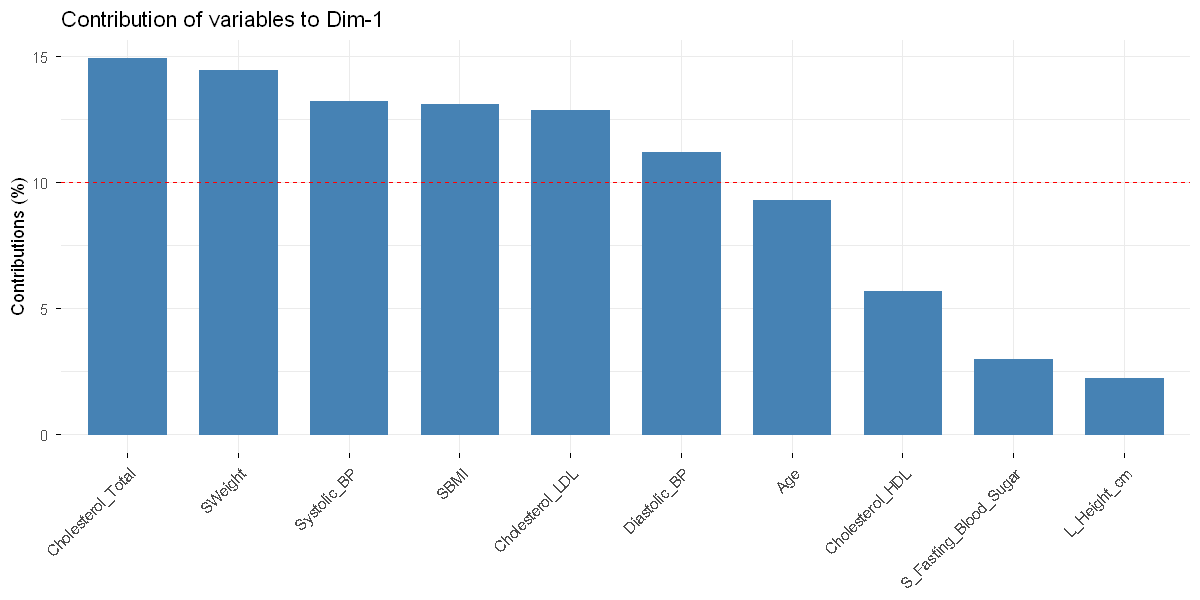

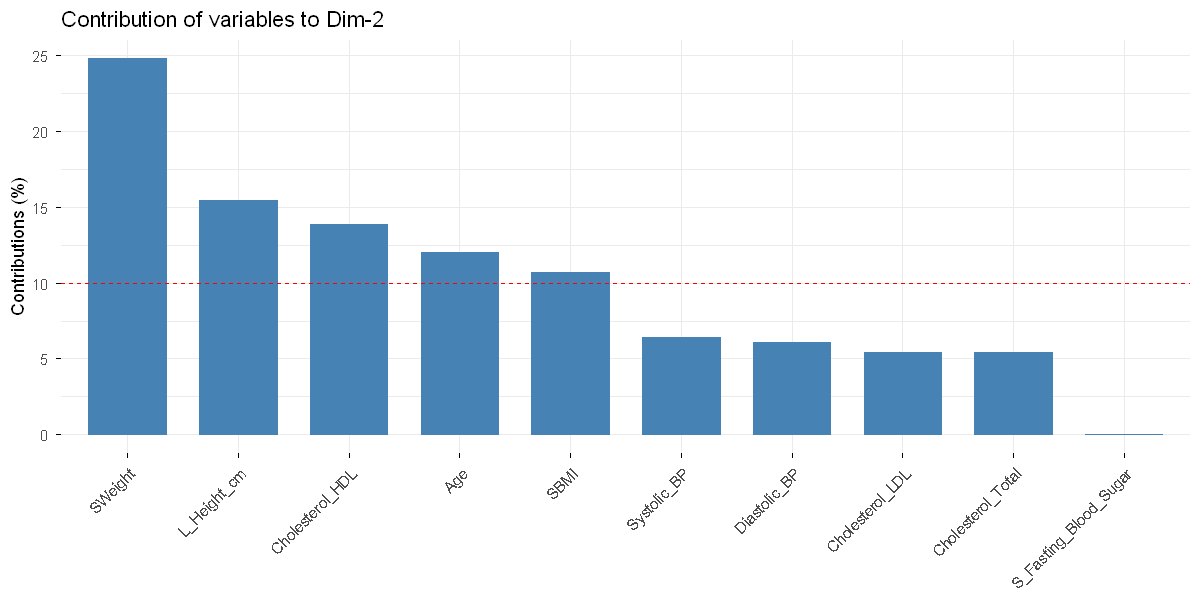

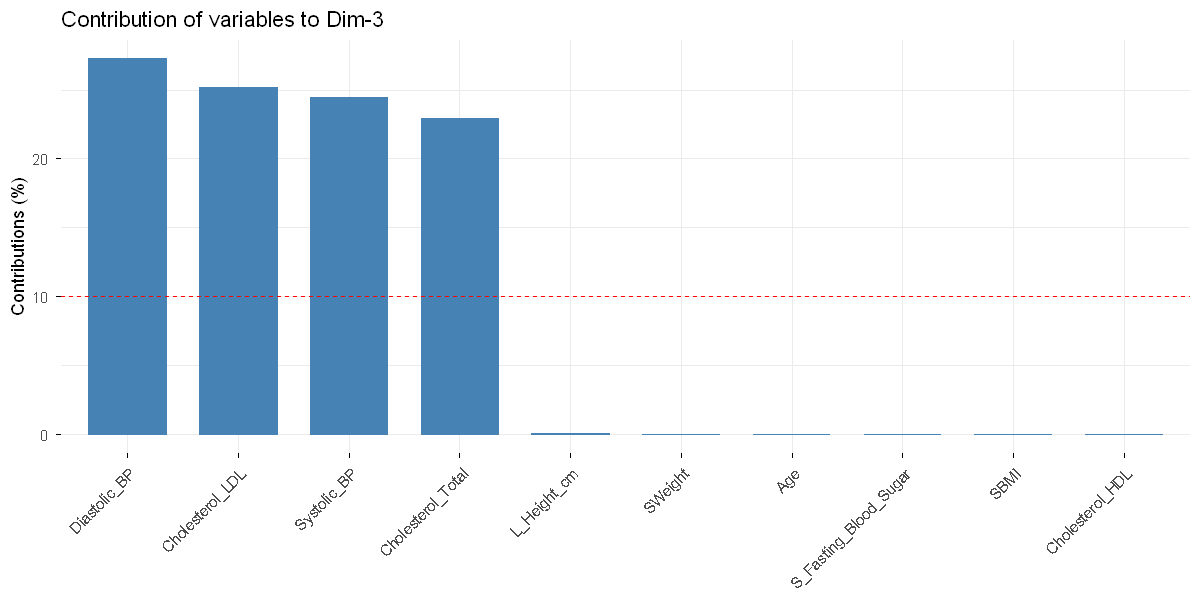

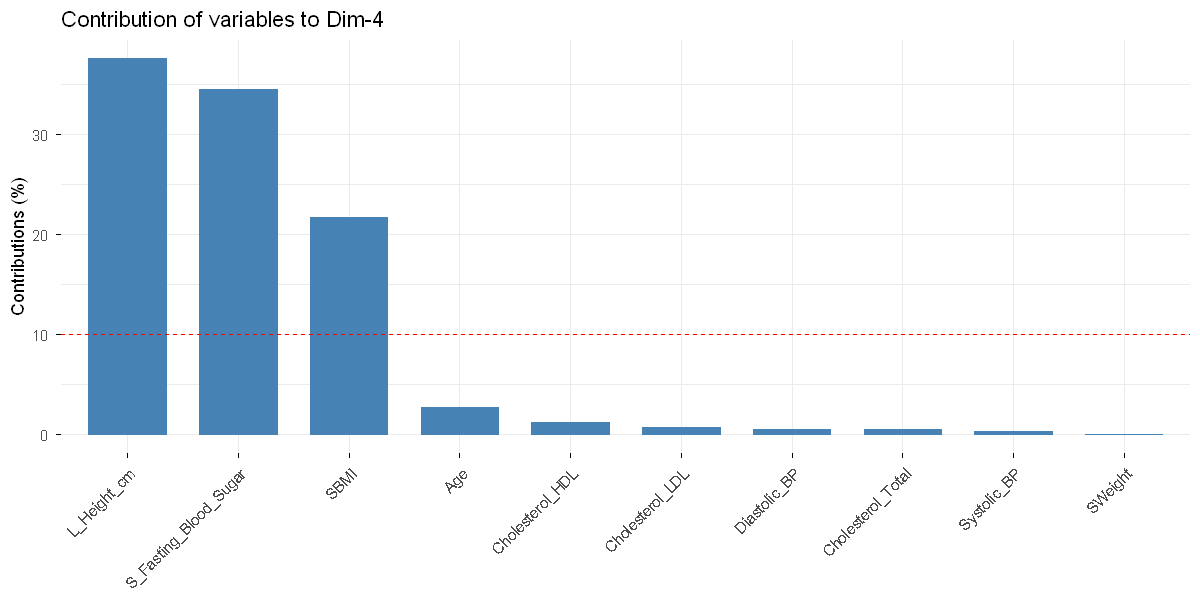

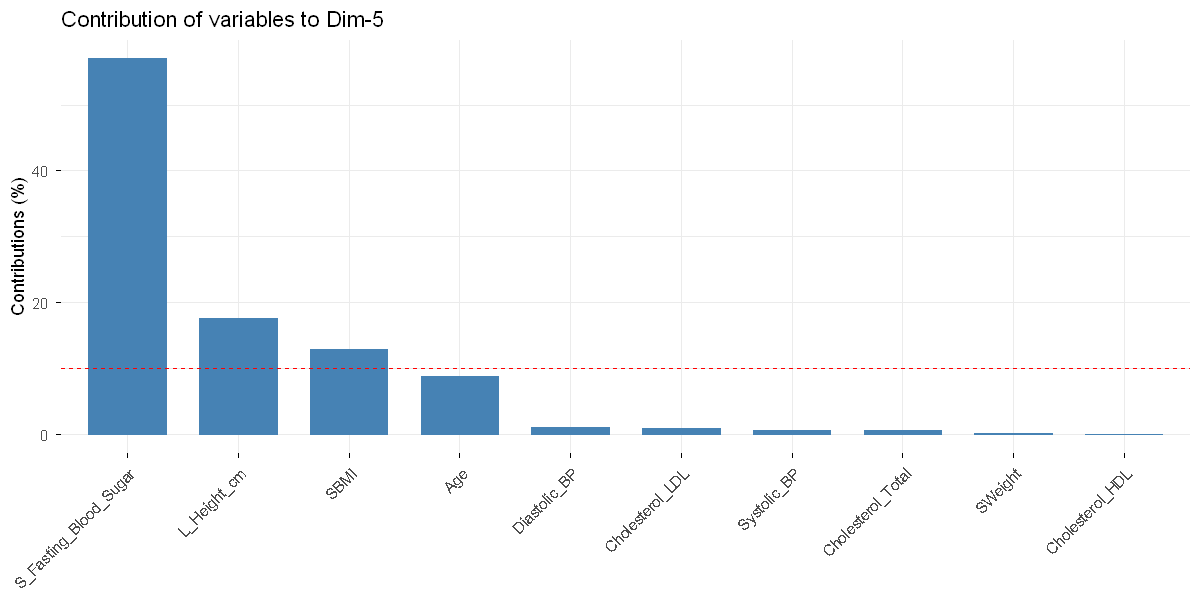

In [16]:
# Visualiser les 30 individus qui contribuent le plus à l'Axe 1
fviz_contrib(res_pca, choice = "var", axes = 1)
fviz_contrib(res_pca, choice = "var", axes = 2) 
fviz_contrib(res_pca, choice = "var", axes = 3)
fviz_contrib(res_pca, choice = "var", axes = 4) 
fviz_contrib(res_pca, choice = "var", axes = 5) 


On voit que la variable S_Fasting_Blood_Sugar contribue significativement à la 5e dimension alors qu'elle contribue très peu 3 première composantes principales

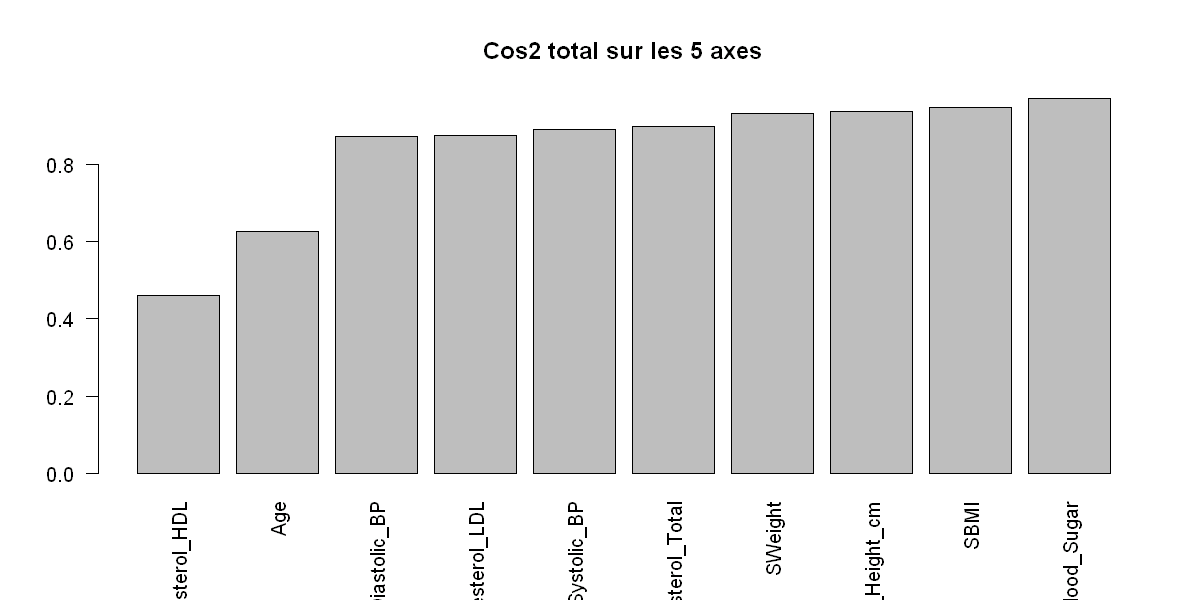

In [17]:
var_cos2_sum <- rowSums(res_pca$var$cos2[, 1:5])
barplot(sort(var_cos2_sum), las=2, main="Cos2 total sur les 5 axes")

L'information de l'age ainsi que du cholestérol n'est pas présente dans les 5 premières composantes principales de l'ACP, elles doivent être surement contenue dans les autres dimensions.

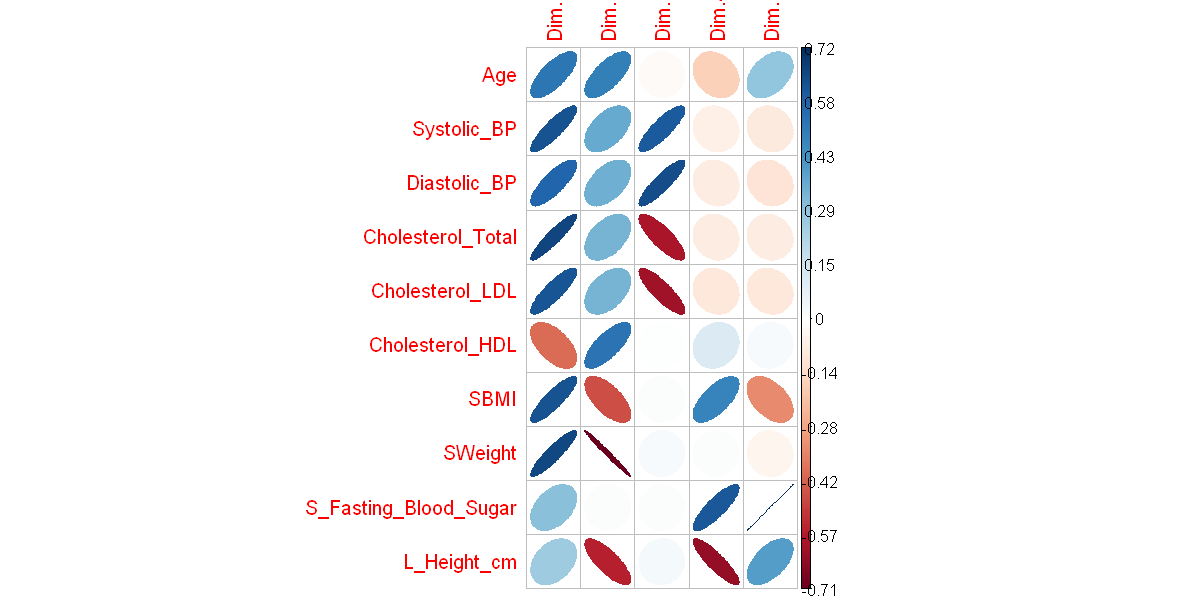

In [18]:
corrplot(res_pca$var$cor, is.corr=FALSE,method="ellipse")

Ce corrplot synthétise la contribution de chaque variable aux axes de l'ACP. La finesse et l'inclinaison des ellipses confirment la polarisation des données : on observe un bloc biométrique (poids et tensions) saturant la Dim 1, tandis que le profil lipidique (LDL) se concentre sur la Dim 2. L'étroitesse des formes sur les dimensions supérieures pour l'âge ou le HDL prouve que ces variables apportent une information spécifique et indépendante, validant ainsi la structure multidimensionnelle du jeu de données.

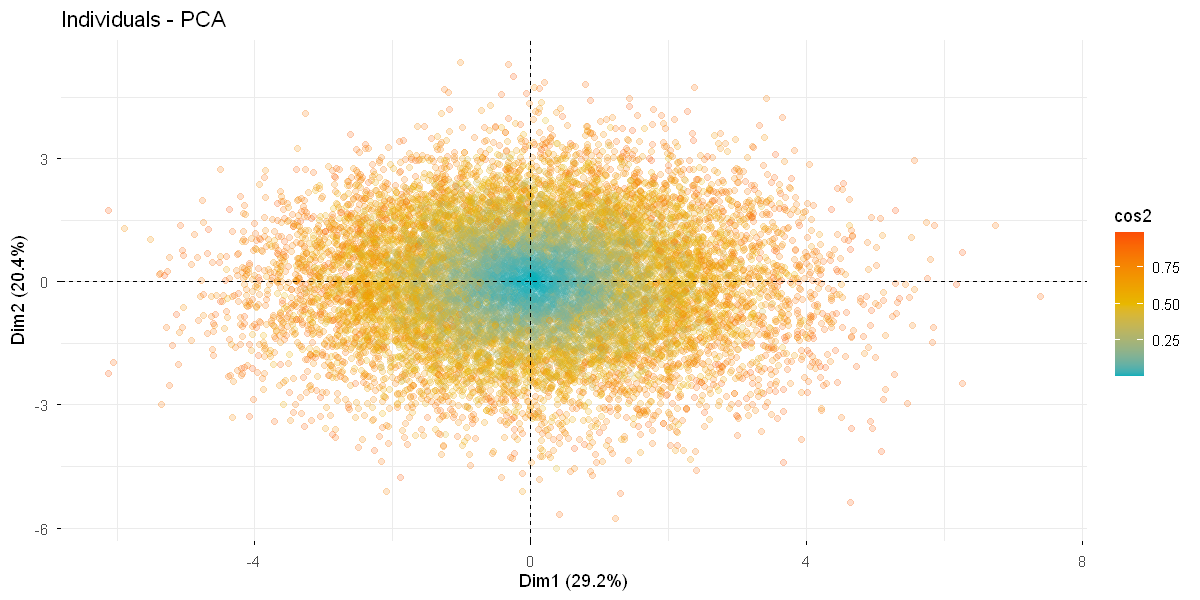

In [19]:
fviz_pca_ind(res_pca, 
             col.ind = "cos2", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             label = "none",        # On cache les noms (trop nombreux)
             alpha.ind = 0.2)

Ce "nuage d'individus" permet de visualiser la structure globale de la population. L'utilisation du $cos^2$ pour la coloration montre que les patients situés en périphérie (en rouge/orangé) sont ceux dont le profil est le mieux expliqué par les axes de poids et de cholestérol. La forte densité centrale indique une population homogène, tandis que l'étalement du nuage confirme la présence d'individus aux profils extrêmes (outliers) qui tirent la variance. 

### Interprétation avec les variables qualitatives

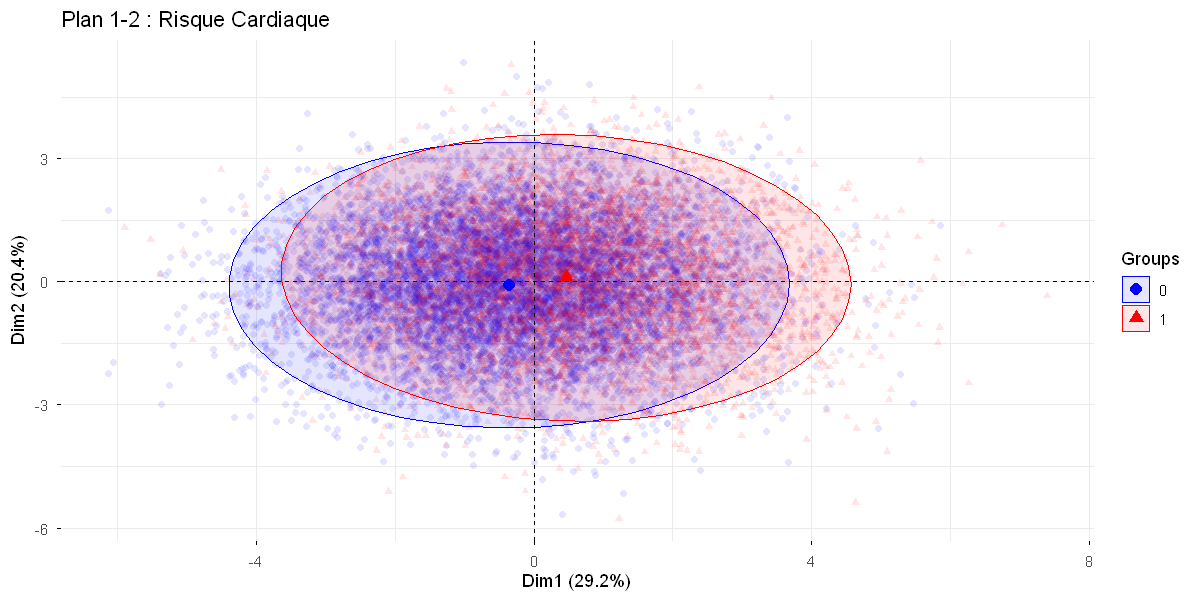

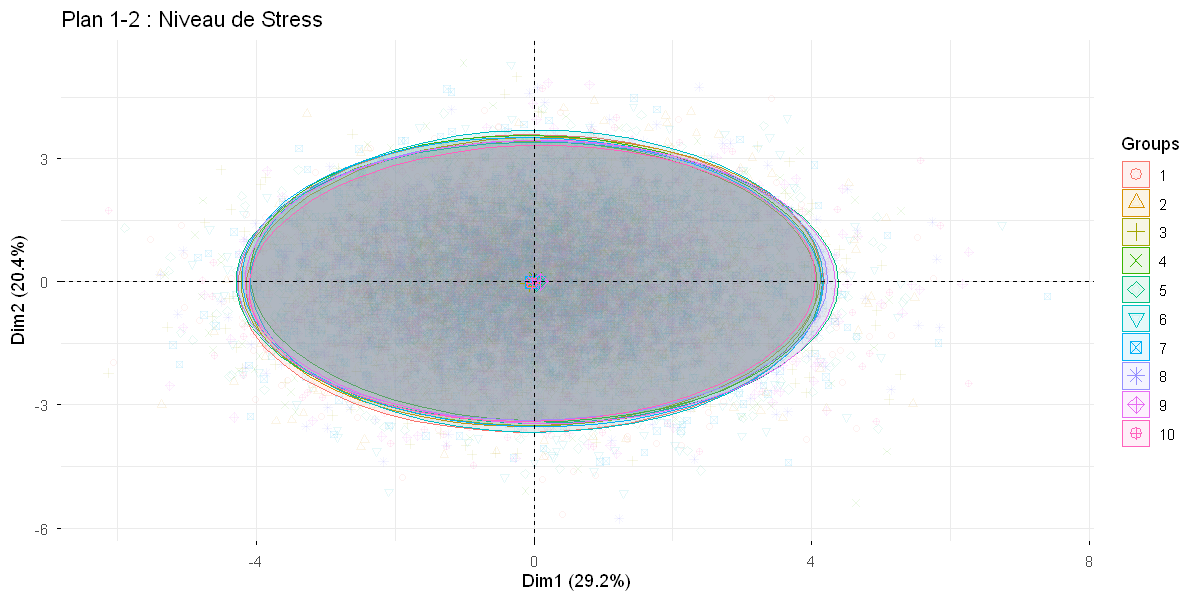

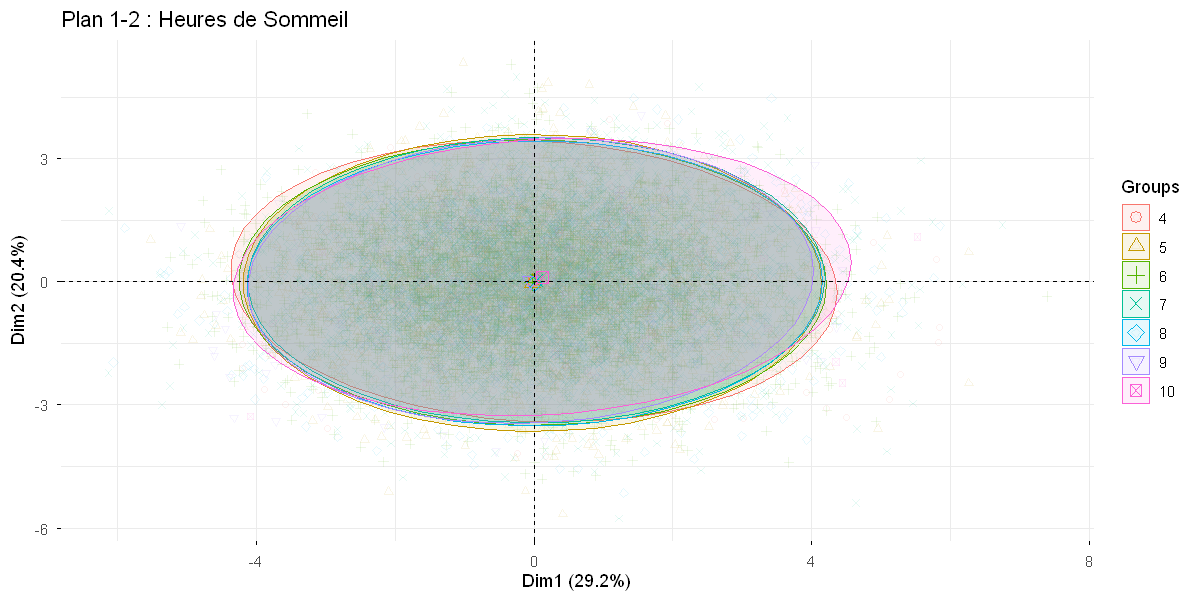

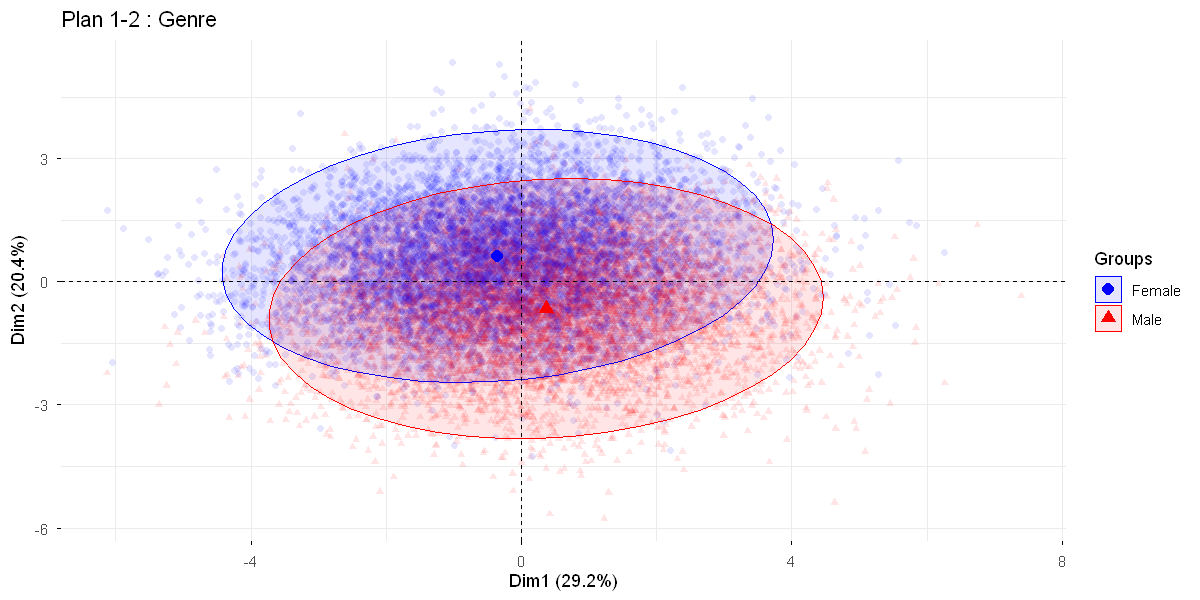

In [21]:

## Plan principal

# Risque Cardiaque 
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(1,2),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-2 : Risque Cardiaque")

# Stress
fviz_pca_ind(res_pca, habillage = data$Stress_Level, axes = c(1,2),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-2 : Niveau de Stress")

# Sommeil

fviz_pca_ind(res_pca, habillage = data$Sleep_Hours, axes = c(1,2),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-2 : Heures de Sommeil")


# Genre
fviz_pca_ind(res_pca, habillage = data$Gender, axes = c(1,2),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-2 : Genre")

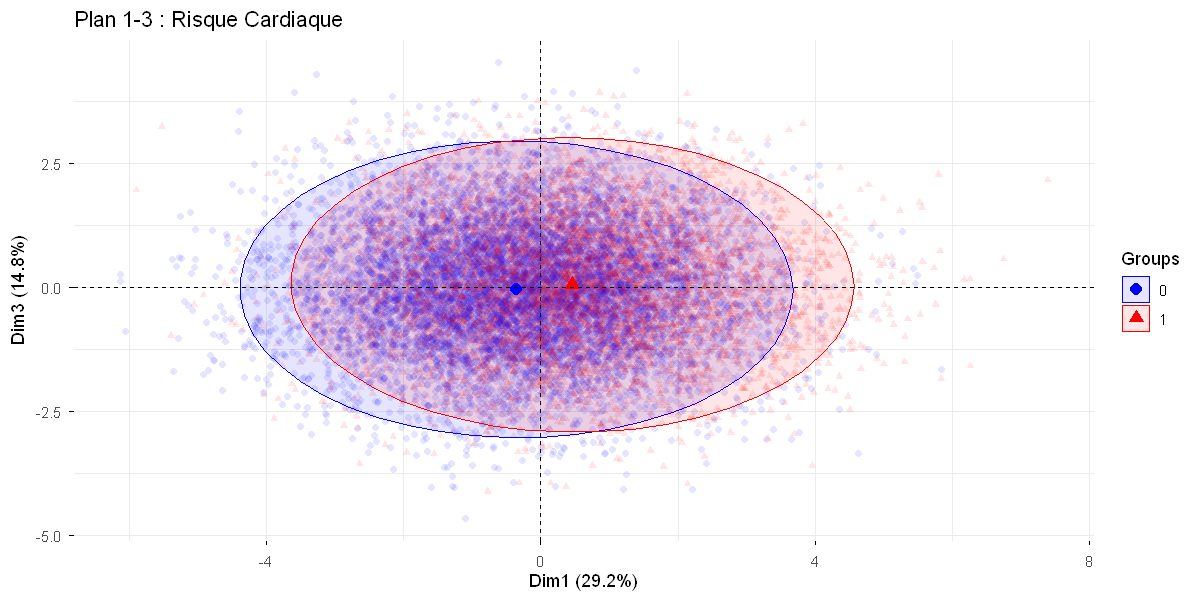

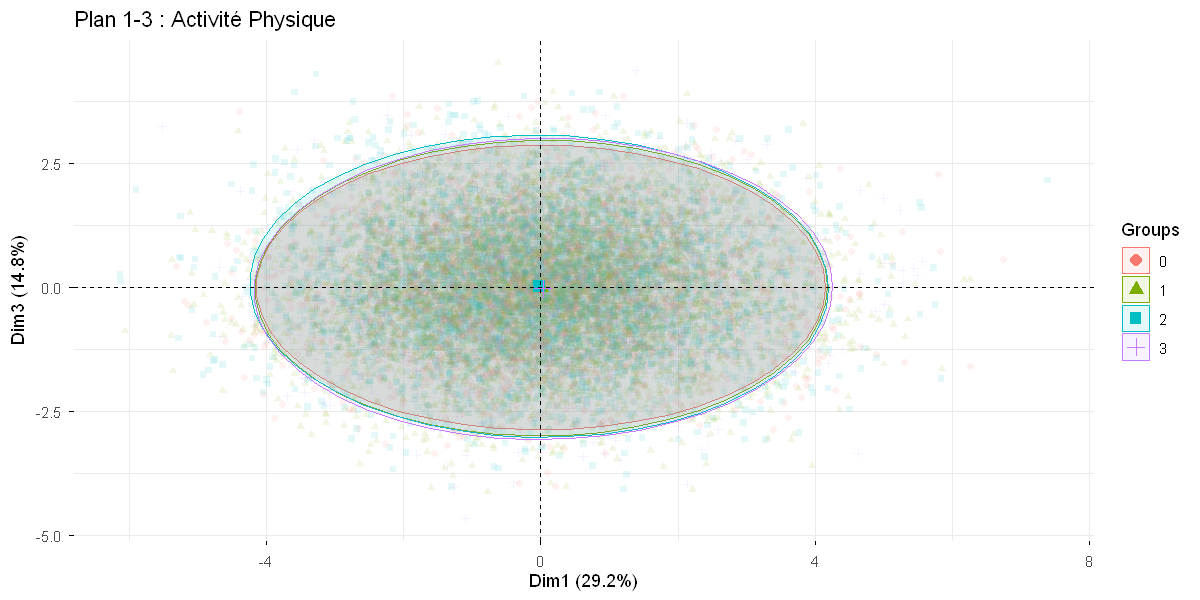

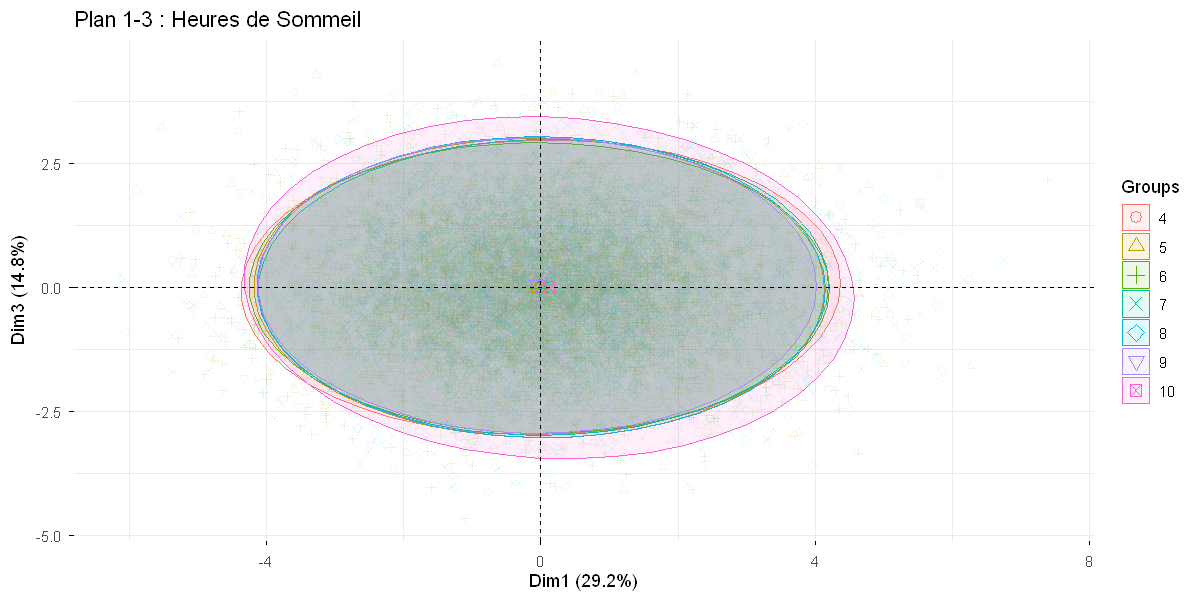

In [24]:
## Plan 1-3

# Risque Cardiaque sur Dim 3
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(1,3),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 1-3 : Risque Cardiaque")

# Activité Physique sur Dim 3 
fviz_pca_ind(res_pca, habillage = data$Physical_Activity_Level, axes = c(1,3),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-3 : Activité Physique")

# Sommeil sur Dim 3
fviz_pca_ind(res_pca, habillage = data$Sleep_Hours, axes = c(1,3),
             label = "none", alpha.ind = 0.1, addEllipses = TRUE,
             title = "Plan 1-3 : Heures de Sommeil")

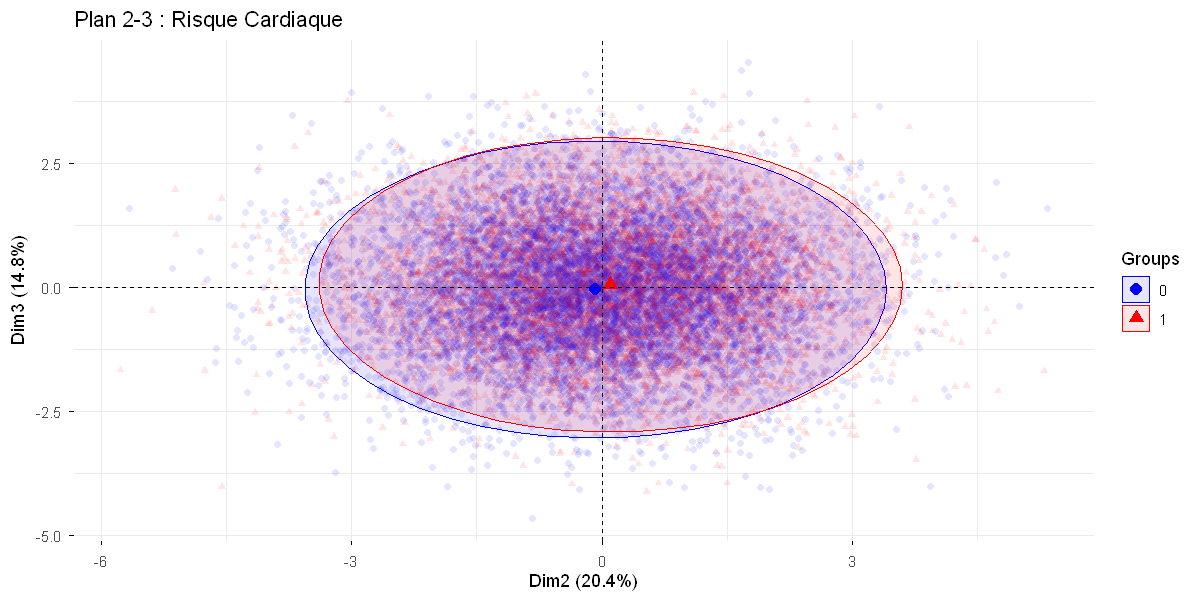

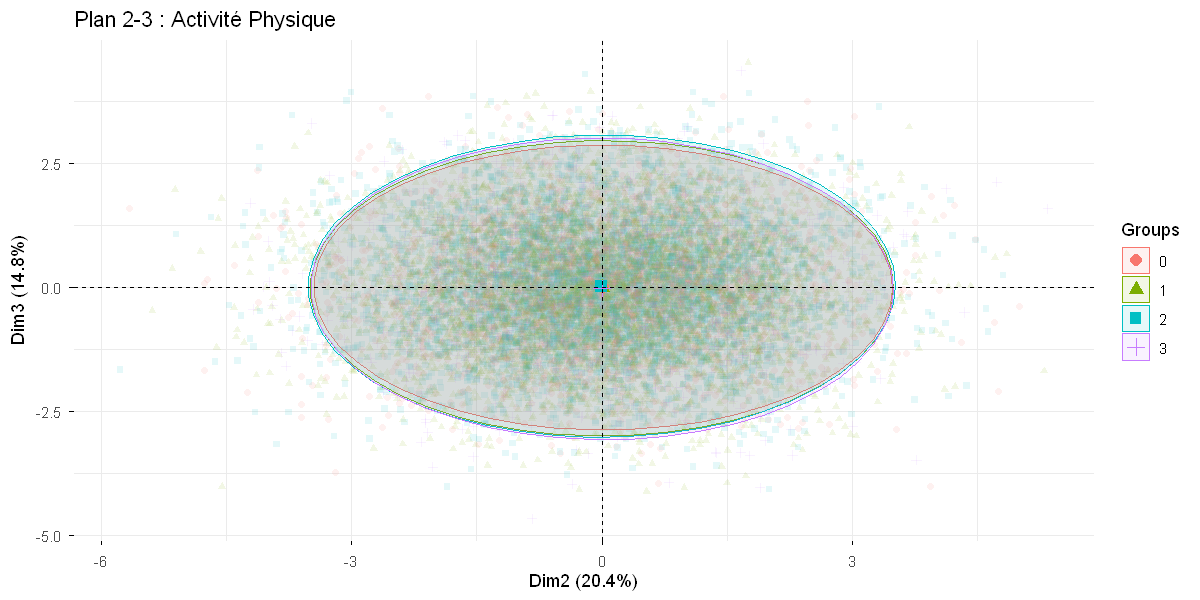

In [ ]:
## Plan 2-3

# Risque Cardiaque sur Dim 2-3
fviz_pca_ind(res_pca, habillage = data$Heart_Disease_Risk, axes = c(2,3),
             label = "none", alpha.ind = 0.1, palette = c("blue", "red"), addEllipses = TRUE,
             title = "Plan 2-3 : Risque Cardiaque")


L'absence de superposition des ellipses signifie que la variable qualitative segmente réellement la population : elle démontre que les groupes possèdent des caractéristiques biologiques distinctes sur ces axes et que cette variable sera donc un prédicteur robuste.

En conclusion, l’ACP a permis de réduire la dimensionnalité de ce jeu de données complexe en identifiant trois leviers de variance indépendants : un pôle biométrique majeur (BMI, tensions), un pôle lipidique (LDL, cholestérol total) et un pôle de facteurs spécifiques (âge, HDL). La projection des variables qualitatives révèle que le risque cardiovasculaire et le niveau de stress sont les facteurs qui segmentent le plus nettement la population, comme en témoigne le décalage des ellipses de confiance sur les premiers plans factoriels. Cette structuration de l’information valide la pertinence des variables sélectionnées et servira de base rigoureuse à la construction de nos modèles prédictifs, en nous permettant de prioriser les variables à fort signal tout en anticipant les problèmes de multicolinéarité.